In [1]:
from config import ROOT_DIR

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
# 데이터 불러오기
kmeans_df = pd.read_csv(ROOT_DIR / 'data/KMeans_clusters.csv')
dbscan_df = pd.read_csv(ROOT_DIR / 'data/DBSCAN_clusters.csv')

# 동일한 고객 기준으로 병합 (CustomerID 기준)
df = pd.merge(kmeans_df, dbscan_df[['CustomerID', 'DBSCAN_Cluster']], on='CustomerID', how='inner')

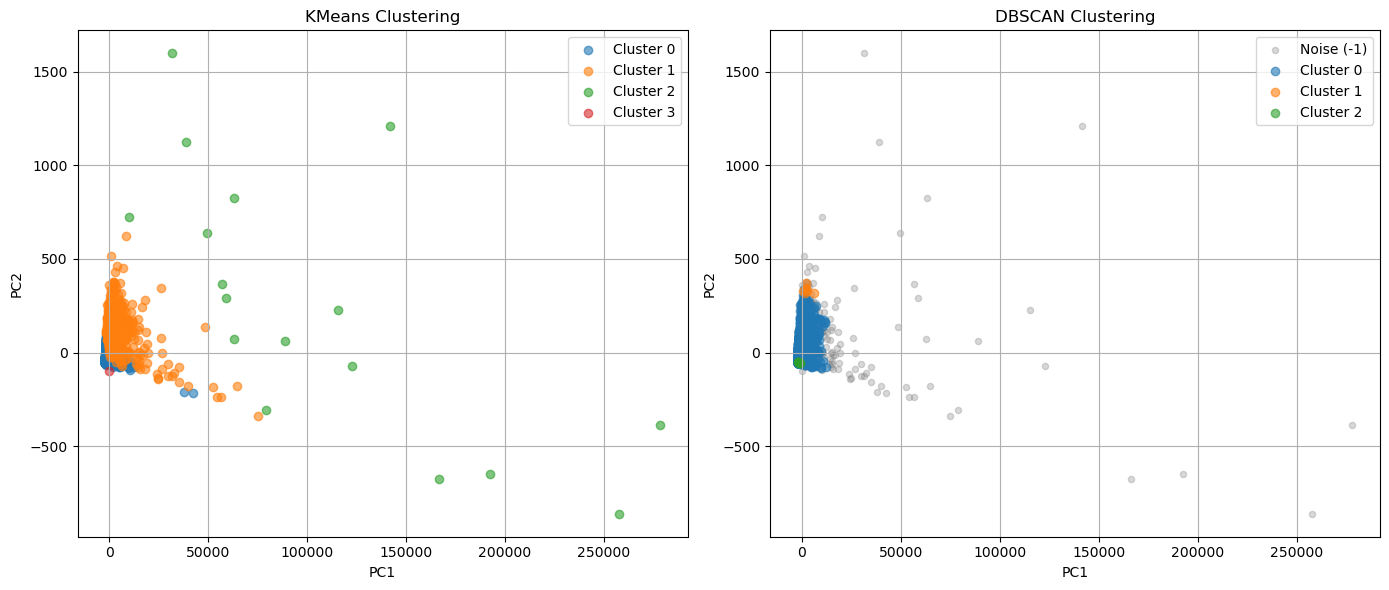

In [3]:
# PCA용 피처
features = ['PurchaseCount', 'TotalSpent', 'AvgUnitPrice', 'UniqueItems']

pca = PCA(n_components=2)
components = pca.fit_transform(df[features])

df['PC1'] = components[:, 0]
df['PC2'] = components[:, 1]

plt.figure(figsize=(14, 6))

# 왼쪽: KMeans 군집 시각화
plt.subplot(1, 2, 1)
for cluster in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', alpha=0.6)
plt.title('KMeans Clustering')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)

# 오른쪽: DBSCAN 군집 시각화
plt.subplot(1, 2, 2)
for cluster in sorted(df['DBSCAN_Cluster'].unique()):
    subset = df[df['DBSCAN_Cluster'] == cluster]
    if cluster == -1:
        plt.scatter(subset['PC1'], subset['PC2'], label='Noise (-1)', color='grey', alpha=0.3, s=20)
    else:
        plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', alpha=0.6)
plt.title('DBSCAN Clustering')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()